In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sys, importlib.util
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import neurite as ne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

2026-03-18 16:55:20.039604: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-18 16:55:20.039654: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-18 16:55:20.041106: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [2]:
_pyc_dir = os.path.abspath(os.path.join('..', '__pycache__'))

def _load_pyc(name):
    pyc = os.path.join(_pyc_dir, f'{name}.cpython-310.pyc')
    spec = importlib.util.spec_from_file_location(name, pyc)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    sys.modules[name] = mod

_load_pyc('tuco_dataset')

from tuco_dataset import TucoDataset
from torch.utils.data import Subset

DOWNSAMPLE = True
torch.backends.cudnn.benchmark = True

DATA_ROOT = '../../Data/Tuco'
MAX_TRAIN = 100
MAX_VAL = None
WINDOW_RADIUS = 3
N_STACK = 2 * WINDOW_RADIUS + 1

def _load_volumes(split, max_n):
    ds = TucoDataset(DATA_ROOT, split=split)
    if max_n is not None:
        ds = Subset(ds, range(min(max_n, len(ds))))
    mr_list, ct_list, mr_seg_list, ct_seg_list = [], [], [], []
    for sample in ds:
        mr_list.append(sample['moving'].squeeze(0).numpy().astype(np.float32))
        ct_list.append(sample['fixed'].squeeze(0).numpy().astype(np.float32))
        mr_seg_list.append(sample['moving_seg'].squeeze(0).numpy().astype(np.int16))
        ct_seg_list.append(sample['fixed_seg'].squeeze(0).numpy().astype(np.int16))
    return mr_list, ct_list, mr_seg_list, ct_seg_list

print('Loading train volumes...')
train_mr_vols, train_ct_vols, train_mr_segs, train_ct_segs = _load_volumes('train', MAX_TRAIN)
print('Loading val volumes...')
val_mr_vols, val_ct_vols, val_mr_segs, val_ct_segs = _load_volumes('val', MAX_VAL)

if DOWNSAMPLE:
    ORIENT_CONFIG = [
        (0, 96,  'axial',    (112, 96)),
        (1, 112, 'coronal',  (96,  96)),
        (2, 96,  'sagittal', (96,  112)),
    ]
else:
    ORIENT_CONFIG = [
        (0, 176, 'axial',    (208, 192)),
        (1, 208, 'coronal',  (176, 192)),
        (2, 192, 'sagittal', (176, 208)),
    ]

SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]
N_LABELS = len(SEG_LABELS)

n_train = len(train_mr_vols)
stacks_per_subj = sum(d - 2*WINDOW_RADIUS for _, d, _, _ in ORIENT_CONFIG)
print(f'Train: {n_train} subjects x {stacks_per_subj} stacks/subj = {n_train * stacks_per_subj} total')
print(f'Val: {len(val_mr_vols)} subjects')
print(f'{N_LABELS} anatomical labels (ignoring 0, 5, 24)')

Loading train volumes...
Found 144 volume pairs for split 'train'
Loading val volumes...
Found 18 volume pairs for split 'val'
Train: 100 subjects x 286 stacks/subj = 28600 total
Val: 18 subjects
16 anatomical labels (ignoring 0, 5, 24)


In [3]:
def multi_orient_generator(mr_vols, ct_vols, mr_segs, ct_segs,
                           batch_size=8, window_radius=WINDOW_RADIUS):
    # Cross-subject, multi-orientation slice-stack generator
    n_subj = len(mr_vols)
    wr = window_radius
    n_stack = 2 * wr + 1

    def _extract_slice(vol, axis, z):
        if axis == 0: return vol[z]
        elif axis == 1: return vol[:, z, :]
        else: return vol[:, :, z]

    def _extract_stack(vol, axis, z):
        if axis == 0: return vol[z-wr : z+wr+1]
        elif axis == 1: return vol[:, z-wr : z+wr+1, :].transpose(1, 0, 2)
        else: return vol[:, :, z-wr : z+wr+1].transpose(2, 0, 1)

    while True:
        axis, D, _, _ = ORIENT_CONFIG[np.random.randint(3)]

        mr_subj_idx = np.random.randint(0, n_subj, size=batch_size)
        ct_subj_idx = np.random.randint(0, n_subj, size=batch_size)
        for k in range(batch_size):
            while ct_subj_idx[k] == mr_subj_idx[k]:
                ct_subj_idx[k] = np.random.randint(0, n_subj)

        z_idx = np.random.randint(wr, D - wr, size=batch_size)

        mr_batch, ct_batch = [], []
        mr_seg_batch, ct_seg_batch = [], []
        for sm, sc, z in zip(mr_subj_idx, ct_subj_idx, z_idx):
            mr_batch.append(np.ascontiguousarray(_extract_stack(mr_vols[sm], axis, z)))
            ct_batch.append(np.ascontiguousarray(_extract_stack(ct_vols[sc], axis, z)))
            mr_seg_batch.append(_extract_slice(mr_segs[sm], axis, z))
            ct_seg_batch.append(_extract_slice(ct_segs[sc], axis, z))

        yield (torch.from_numpy(np.stack(mr_batch)).to(device),
               torch.from_numpy(np.stack(ct_batch)).to(device),
               torch.from_numpy(np.stack(mr_seg_batch)).to(device),
               torch.from_numpy(np.stack(ct_seg_batch)).to(device))

In [4]:
class SpatialTransformer2D(nn.Module):
    def forward(self, src, flow):
        b, _, h, w = src.shape
        device = src.device
        yy, xx = torch.meshgrid(
            torch.arange(h, device=device),
            torch.arange(w, device=device), indexing='ij')
        base_grid = torch.stack((xx, yy), 0).float().unsqueeze(0).repeat(b, 1, 1, 1).to(flow)
        pts = base_grid + flow
        x = 2.0 * (pts[:, 0] / (w - 1)) - 1.0
        y = 2.0 * (pts[:, 1] / (h - 1)) - 1.0
        grid = torch.stack((x, y), dim=-1)
        return F.grid_sample(src, grid, mode='bilinear', padding_mode='border', align_corners=True)


def flow_grad_l2(flow):
    dx = flow[:, :, :, 1:] - flow[:, :, :, :-1]
    dy = flow[:, :, 1:, :] - flow[:, :, :-1, :]
    return F.pad(dx, (0, 1)).pow(2).mean() + F.pad(dy, (0, 0, 0, 1)).pow(2).mean()


def seg_to_onehot_2d(seg, labels=SEG_LABELS):
    seg_long = seg.long()
    onehot = torch.zeros(seg.shape[0], len(labels), *seg.shape[1:],
                         device=seg.device, dtype=torch.float32)
    for i, lbl in enumerate(labels):
        onehot[:, i] = (seg_long == lbl).float()
    return onehot


def dice_loss_2d(pred_onehot, gt_onehot, eps=1e-5):
    dims = (2, 3)
    intersection = (pred_onehot * gt_onehot).sum(dim=dims)
    union = pred_onehot.sum(dim=dims) + gt_onehot.sum(dim=dims)
    dice_per_label = (2.0 * intersection + eps) / (union + eps)
    return 1.0 - dice_per_label.mean()

In [5]:
class ConvBlock2D(nn.Module):
    # DPU-compatible Conv+LeakyReLU block
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        # Success: LeakyReLU alpha=0.1 (Vitis AI 2.5 requirement!)
        self.act = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.act(self.conv(x))


class VxmDense2p5D(nn.Module):
    # 2

    def __init__(self, n_stack, enc_feats=(16, 32, 32, 32), final_feats=(32, 16)):
        super().__init__()
        self.n_stack = n_stack
        self.center = n_stack // 2

        # Encoder (DPU-compatible)
        self.encoders = nn.ModuleList()
        in_ch = 2 * n_stack
        for nf in enc_feats:
            self.encoders.append(ConvBlock2D(in_ch, nf))
            in_ch = nf

        # Success: Strided Conv2D for downsampling (replaces MaxPool2D)
        self.downsample = nn.ModuleList()
        for nf in enc_feats:
            self.downsample.append(nn.Sequential(
                nn.Conv2d(nf, nf, kernel_size=3, stride=2, padding=1),
                nn.LeakyReLU(0.1)
            ))
        
        # Bottleneck (DPU-compatible)
        self.bottleneck = ConvBlock2D(enc_feats[-1], enc_feats[-1])

        # Decoder (DPU-compatible)
        self.decoders = nn.ModuleList()
        dec_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock2D(dec_in + skip_ch, skip_ch))
            dec_in = skip_ch

        # Flow head (DPU-compatible)
        self.final_conv0 = ConvBlock2D(dec_in, final_feats[0])
        self.final_conv1 = ConvBlock2D(final_feats[0], final_feats[1])
        self.flow = nn.Conv2d(final_feats[1], 2, kernel_size=3, padding=1)
        
        # Spatial transformer (CPU-only, NOT exported for FPGA)
        self.transformer = SpatialTransformer2D()

        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, src_stack, tgt_stack):
    # Full forward pass (training mode - includes transformer) Args: src_stack: (B, n_stack, H, W) moving image stack tgt_stack: (B, n_stack, H, W) fixed image stack Returns: moved: (B, 1, H, W) warped center slice flow: (B, 2, H, W) predicted flow field
        x = torch.cat([src_stack, tgt_stack], dim=1)
        skips = []
        
        # Encoder with strided conv downsampling
        for enc, ds in zip(self.encoders, self.downsample):
            x = enc(x)
            skips.append(x)
            x = ds(x)  # Strided conv instead of MaxPool

        x = self.bottleneck(x)

        # Decoder with skip connections
        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        x = self.final_conv0(x)
        x = self.final_conv1(x)
        flow = self.flow(x)
        
        # Apply spatial transformer (only during training)
        src_center = src_stack[:, self.center : self.center + 1]
        moved = self.transformer(src_center, flow)
        return moved, flow
    
    def forward_flow_only(self, src_stack, tgt_stack):
    # Flow-only forward pass (FPGA deployment mode - NO transformer) Use this for ONNX export / Vitis AI compilation Args: src_stack: (B, n_stack, H, W) moving image stack tgt_stack: (B, n_stack, H, W) fixed image stack Returns: flow: (B, 2, H, W) predicted flow field only
        x = torch.cat([src_stack, tgt_stack], dim=1)
        skips = []
        
        # Encoder
        for enc, ds in zip(self.encoders, self.downsample):
            x = enc(x)
            skips.append(x)
            x = ds(x)

        x = self.bottleneck(x)

        # Decoder
        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        x = self.final_conv0(x)
        x = self.final_conv1(x)
        flow = self.flow(x)
        
        return flow  # Return flow only, no transformer

In [6]:
model = VxmDense2p5D(n_stack=N_STACK).to(device)
model.eval()
_gen = multi_orient_generator(train_mr_vols, train_ct_vols,
                               train_mr_segs, train_ct_segs, batch_size=2)
for _ in range(3):
    with torch.no_grad():
        _mr, _ct, _ms, _fs = next(_gen)
        _moved, _flow = model(_mr, _ct)
        _ms_oh = seg_to_onehot_2d(_ms)
        _moved_seg = model.transformer(_ms_oh, _flow)
        _fs_oh = seg_to_onehot_2d(_fs)
        _dl = dice_loss_2d(_moved_seg, _fs_oh)
    print(f'  input: {tuple(_mr.shape)} -> moved: {tuple(_moved.shape)}, dice_loss: {_dl.item():.4f}')
del _mr, _ct, _ms, _fs, _moved, _flow, _ms_oh, _fs_oh, _moved_seg, _dl, _gen
torch.cuda.empty_cache()

print(f'VRAM after init: {torch.cuda.memory_allocated()/1e6:.0f} MB  |  GPU: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

  input: (2, 7, 208, 192) -> moved: (2, 1, 208, 192), dice_loss: 0.4047
  input: (2, 7, 176, 192) -> moved: (2, 1, 176, 192), dice_loss: 0.1595
  input: (2, 7, 176, 192) -> moved: (2, 1, 176, 192), dice_loss: 0.1979
VRAM after init: 1 MB  |  GPU: 12.9 GB


In [7]:
batch_size = 8
steps_per_epoch = 200
val_steps = 50
epochs = 1500
smooth_weight = 0.1
ckpt_every = 50

save_dir = '../trained_weights'
ckpt_dir = os.path.join(save_dir, '2p5d_checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, '2p5d_dense_best.pth')

model = VxmDense2p5D(n_stack=N_STACK).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_history = []
val_history = []
best_loss = float('inf')

train_gen = multi_orient_generator(train_mr_vols, train_ct_vols,
                                    train_mr_segs, train_ct_segs,
                                    batch_size=batch_size)

print('Pre-computing fixed validation batches...')
_val_gen = multi_orient_generator(val_mr_vols, val_ct_vols,
                                   val_mr_segs, val_ct_segs,
                                   batch_size=batch_size)
val_batches = []
for _ in range(val_steps):
    mr_s, ct_s, mr_seg, ct_seg = next(_val_gen)
    val_batches.append((mr_s.cpu(), ct_s.cpu(), mr_seg.cpu(), ct_seg.cpu()))
del _val_gen
print(f'{len(val_batches)} fixed val batches cached')
print(f'\nTraining: {steps_per_epoch} steps/epoch, {epochs} epochs')
print(f'Loss: Dice + {smooth_weight} x smooth | Cross-subject | Multi-orientation')

for epoch in range(epochs):
    model.train()
    running_train = 0.0
    nan_steps = 0
    for _ in range(steps_per_epoch):
        mr_stack, ct_stack, mr_seg_c, ct_seg_c = next(train_gen)
        optimizer.zero_grad(set_to_none=True)
        moved, flow = model(mr_stack, ct_stack)
        smooth_loss = flow_grad_l2(flow)
        ms_oh = seg_to_onehot_2d(mr_seg_c)
        fs_oh = seg_to_onehot_2d(ct_seg_c)
        moved_seg_oh = model.transformer(ms_oh, flow)
        d_loss = dice_loss_2d(moved_seg_oh, fs_oh)
        loss = d_loss + smooth_weight * smooth_loss

        if not torch.isfinite(loss):
            nan_steps += 1
            continue

        loss.backward()
        optimizer.step()
        running_train += loss.item()

    valid_steps = steps_per_epoch - nan_steps
    epoch_train = running_train / max(valid_steps, 1)
    train_history.append(epoch_train)

    if epoch % 10 == 0:
        torch.cuda.empty_cache()

    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for mr_v, ct_v, mrs_v, cts_v in val_batches:
            mr_s = mr_v.to(device)
            ct_s = ct_v.to(device)
            mrs_c = mrs_v.to(device)
            cts_c = cts_v.to(device)
            moved_v, flow_v = model(mr_s, ct_s)
            smooth_v = flow_grad_l2(flow_v)
            ms_oh = seg_to_onehot_2d(mrs_c)
            fs_oh = seg_to_onehot_2d(cts_c)
            moved_seg_oh = model.transformer(ms_oh, flow_v)
            d_loss_v = dice_loss_2d(moved_seg_oh, fs_oh)
            loss_v = d_loss_v + smooth_weight * smooth_v
            running_val += loss_v.item()

    epoch_val = running_val / len(val_batches)
    val_history.append(epoch_val)

    nan_str = f'  ({nan_steps} NaN)' if nan_steps else ''
    print(f'Epoch {epoch+1}/{epochs} -- train: {epoch_train:.6f} | val: {epoch_val:.6f}{nan_str}')

    if (epoch + 1) % ckpt_every == 0:
        ckpt_path = os.path.join(ckpt_dir, f'2p5d_epoch_{epoch+1}.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_train,
            'val_loss': epoch_val,
            'best_val_loss': best_loss,
        }, ckpt_path)

    if epoch_val < best_loss:
        best_loss = epoch_val
        torch.save(model.state_dict(), best_model_path)

train_history = np.array(train_history, dtype=np.float32)
val_history = np.array(val_history, dtype=np.float32)
print(f'Best val loss: {best_loss:.6f}')
print(f'Peak VRAM: {torch.cuda.max_memory_allocated()/1e6:.0f} MB')

Pre-computing fixed validation batches...
50 fixed val batches cached

Training: 200 steps/epoch, 1500 epochs
Loss: Dice + 0.1 x smooth | Cross-subject | Multi-orientation
Epoch 1/1500 -- train: 0.161518 | val: 0.175609
Epoch 2/1500 -- train: 0.167330 | val: 0.175468
Epoch 3/1500 -- train: 0.170730 | val: 0.175369
Epoch 4/1500 -- train: 0.167413 | val: 0.174861
Epoch 5/1500 -- train: 0.164321 | val: 0.174438
Epoch 6/1500 -- train: 0.161149 | val: 0.174631
Epoch 7/1500 -- train: 0.168557 | val: 0.174305
Epoch 8/1500 -- train: 0.174746 | val: 0.174078
Epoch 9/1500 -- train: 0.169146 | val: 0.175807
Epoch 10/1500 -- train: 0.159679 | val: 0.173968
Epoch 11/1500 -- train: 0.160354 | val: 0.173168
Epoch 12/1500 -- train: 0.164658 | val: 0.173547
Epoch 13/1500 -- train: 0.162236 | val: 0.172661
Epoch 14/1500 -- train: 0.164944 | val: 0.172058
Epoch 15/1500 -- train: 0.160760 | val: 0.171895
Epoch 16/1500 -- train: 0.163175 | val: 0.171962
Epoch 17/1500 -- train: 0.168027 | val: 0.171570
Epoc

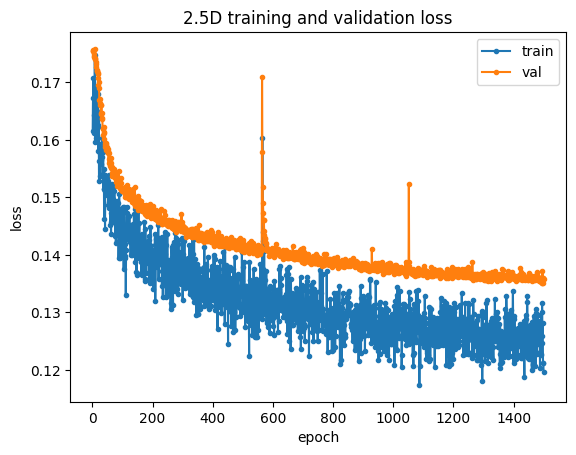

In [8]:
epochs_ran = np.arange(1, len(train_history) + 1)
plt.figure()
plt.plot(epochs_ran, train_history, '.-', label='train')
plt.plot(epochs_ran, val_history,   '.-', label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('2.5D training and validation loss')
plt.legend()
plt.show()

--- AXIAL ---


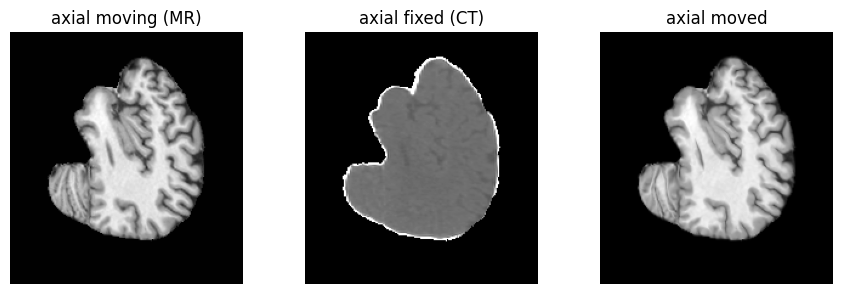

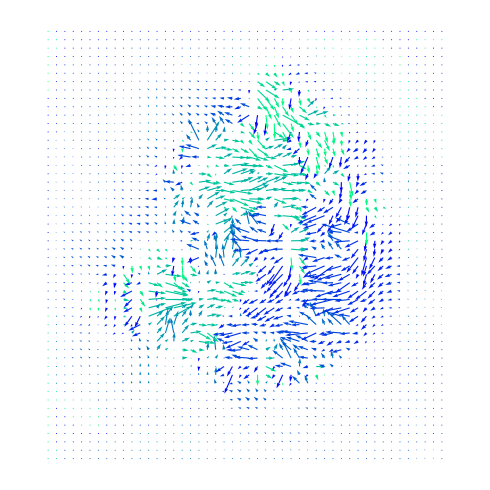

--- CORONAL ---


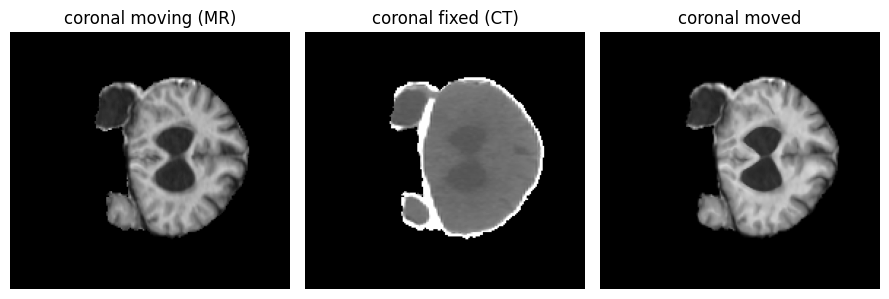

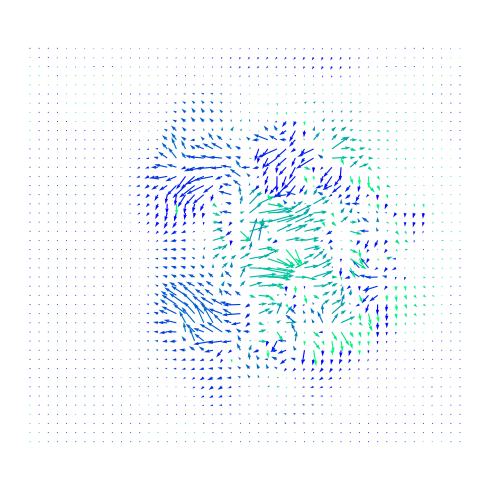

--- SAGITTAL ---


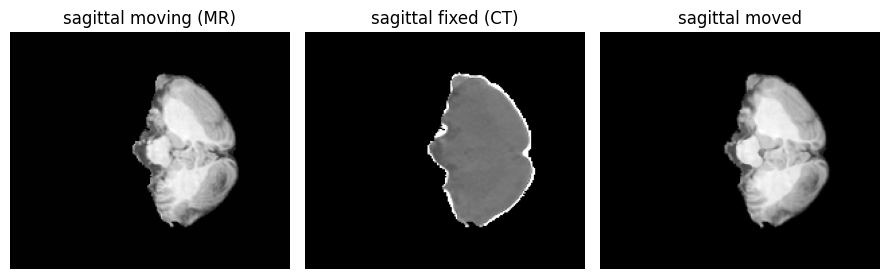

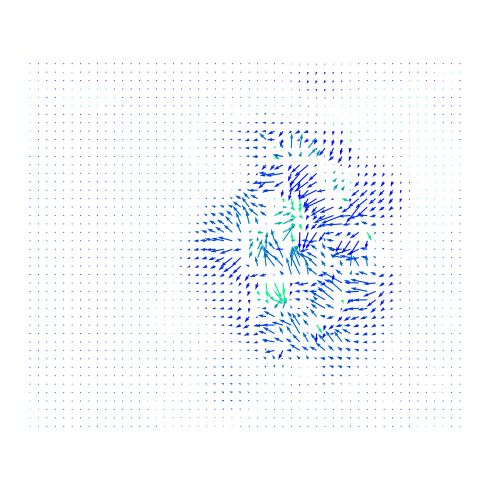

In [9]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()


def visualise_orientation(orient_name, mr_vols, ct_vols):
    axis, D, name, _ = next(c for c in ORIENT_CONFIG if c[2] == orient_name)
    wr = WINDOW_RADIUS
    center = N_STACK // 2

    s = np.random.randint(len(mr_vols))
    z = D // 2

    if axis == 0:
        mr_stack = mr_vols[s][z-wr : z+wr+1]
        ct_stack = ct_vols[s][z-wr : z+wr+1]
    elif axis == 1:
        mr_stack = mr_vols[s][:, z-wr : z+wr+1, :].transpose(1, 0, 2)
        ct_stack = ct_vols[s][:, z-wr : z+wr+1, :].transpose(1, 0, 2)
    else:
        mr_stack = mr_vols[s][:, :, z-wr : z+wr+1].transpose(2, 0, 1)
        ct_stack = ct_vols[s][:, :, z-wr : z+wr+1].transpose(2, 0, 1)

    mr_t = torch.from_numpy(np.ascontiguousarray(mr_stack))[None].to(device)
    ct_t = torch.from_numpy(np.ascontiguousarray(ct_stack))[None].to(device)

    with torch.no_grad():
        moved, flow = model(mr_t, ct_t)

    plt.figure(figsize=(9, 3))
    for i, (img, title) in enumerate([
            (mr_stack[center], 'moving (MR)'),
            (ct_stack[center], 'fixed (CT)'),
            (moved[0, 0].cpu().numpy(), 'moved')]):
        plt.subplot(1, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'{orient_name} {title}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    flow_np = flow[0].permute(1, 2, 0).cpu().numpy()
    ne.plot.flow([flow_np[::4, ::4, :]], width=5)


for orient in ['axial', 'coronal', 'sagittal']:
    print(f'--- {orient.upper()} ---')
    visualise_orientation(orient, val_mr_vols, val_ct_vols)

In [10]:
from scipy.ndimage import distance_transform_edt
import time


def compute_dice_per_label(warped_seg, fixed_seg, labels=SEG_LABELS):
    dice_scores = []
    for lbl in labels:
        w = (warped_seg == lbl).astype(np.float32)
        f = (fixed_seg == lbl).astype(np.float32)
        inter = (w * f).sum()
        union = w.sum() + f.sum()
        dice_scores.append(1.0 if union == 0 else 2.0 * inter / union)
    return np.array(dice_scores)


def hausdorff_distance_95(seg1, seg2):
    if seg1.sum() == 0 and seg2.sum() == 0: return 0.0
    if seg1.sum() == 0 or seg2.sum() == 0: return np.inf
    dt2 = distance_transform_edt(~seg2.astype(bool))
    dt1 = distance_transform_edt(~seg1.astype(bool))
    d12 = dt2[seg1.astype(bool)]
    d21 = dt1[seg2.astype(bool)]
    return max(np.percentile(d12, 95), np.percentile(d21, 95))


def negative_jacobian_ratio_2d(flow_np):
    H, W, _ = flow_np.shape
    grid_h, grid_w = np.mgrid[:H, :W].astype(np.float32)
    deform = flow_np.copy()
    deform[..., 0] += grid_h
    deform[..., 1] += grid_w
    d00 = np.gradient(deform[..., 0], axis=0)
    d01 = np.gradient(deform[..., 0], axis=1)
    d10 = np.gradient(deform[..., 1], axis=0)
    d11 = np.gradient(deform[..., 1], axis=1)
    det = d00 * d11 - d01 * d10
    return np.sum(det <= 0) / det.size


def infer_volume_2p5d(model, mr_vol, ct_vol, axis=0, window_radius=WINDOW_RADIUS):
    wr = window_radius
    D = mr_vol.shape[axis]
    flows = []

    torch.cuda.synchronize()
    t0 = time.time()

    for z in range(wr, D - wr):
        if axis == 0:
            mr_stack = mr_vol[z-wr:z+wr+1]
            ct_stack = ct_vol[z-wr:z+wr+1]
        elif axis == 1:
            mr_stack = mr_vol[:, z-wr:z+wr+1, :].transpose(1, 0, 2)
            ct_stack = ct_vol[:, z-wr:z+wr+1, :].transpose(1, 0, 2)
        else:
            mr_stack = mr_vol[:, :, z-wr:z+wr+1].transpose(2, 0, 1)
            ct_stack = ct_vol[:, :, z-wr:z+wr+1].transpose(2, 0, 1)

        mr_t = torch.from_numpy(np.ascontiguousarray(mr_stack))[None].to(device)
        ct_t = torch.from_numpy(np.ascontiguousarray(ct_stack))[None].to(device)
        _, flow = model(mr_t, ct_t)
        flows.append(flow[0].cpu().numpy())

    torch.cuda.synchronize()
    return np.stack(flows).transpose(0, 2, 3, 1), time.time() - t0


n_val = len(val_mr_vols)
np.random.seed(42)
indices = np.random.permutation(n_val)
n_pairs = n_val // 2
pairings = [(indices[2*i], indices[2*i+1]) for i in range(n_pairs)]
print(f'{n_val} val subjects, {n_pairs} cross-subject pairs\n')

dice_all, hd95_all, jacobian_all, infer_times = [], [], [], []

model.eval()
with torch.no_grad():
    for pair_idx, (i, j) in enumerate(pairings):
        print(f'  Pair {pair_idx+1}/{n_pairs}: subj {i} (MR) -> subj {j} (CT)')

        flow_stack, duration = infer_volume_2p5d(model, val_mr_vols[i], val_ct_vols[j], axis=0)
        if pair_idx > 0:
            infer_times.append(duration)

        wr = WINDOW_RADIUS
        D = val_mr_vols[i].shape[0]
        mr_seg = val_mr_segs[i]
        ct_seg = val_ct_segs[j]

        warped_labels = np.zeros_like(mr_seg)
        for si, z in enumerate(range(wr, D - wr)):
            flow_2d = flow_stack[si]
            flow_t = torch.from_numpy(flow_2d.transpose(2, 0, 1))[None].float().to(device)
            seg_oh = seg_to_onehot_2d(
                torch.from_numpy(mr_seg[z].astype(np.int64))[None].to(device))

            _, _, h, w = seg_oh.shape
            yy, xx = torch.meshgrid(
                torch.arange(h, device=device), torch.arange(w, device=device), indexing='ij')
            base = torch.stack((xx, yy), dim=0).float().unsqueeze(0)
            pts = base + flow_t
            gx = 2.0 * (pts[:, 0] / (w - 1)) - 1.0
            gy = 2.0 * (pts[:, 1] / (h - 1)) - 1.0
            grid = torch.stack((gx, gy), dim=-1)
            warped_oh = F.grid_sample(seg_oh, grid, mode='nearest',
                                      padding_mode='border', align_corners=True)
            warped_np = warped_oh[0].cpu().numpy()
            for li, lbl in enumerate(SEG_LABELS):
                warped_labels[z][warped_np[li] > 0.5] = lbl

        warped_eval = warped_labels[wr:D-wr]
        fixed_eval = ct_seg[wr:D-wr]

        dice_all.append(compute_dice_per_label(warped_eval, fixed_eval))

        hd95_per_label = []
        for lbl in SEG_LABELS:
            hd95_per_label.append(hausdorff_distance_95(
                (warped_eval == lbl).astype(np.uint8),
                (fixed_eval == lbl).astype(np.uint8)))
        hd95_all.append(np.mean(hd95_per_label))

        jac_ratios = [negative_jacobian_ratio_2d(flow_stack[si]) for si in range(flow_stack.shape[0])]
        jacobian_all.append(np.mean(jac_ratios))
        torch.cuda.empty_cache()

dice_all = np.stack(dice_all)
dice_means = dice_all.mean(axis=1) * 100

print(f'\nAvg Dice: {dice_means.mean():.2f} +/- {dice_means.std():.2f} %')
print(f'|J| <= 0: {np.mean(jacobian_all):.6f} +/- {np.std(jacobian_all):.6f}')
print(f'HD95: {np.mean(hd95_all):.2f} +/- {np.std(hd95_all):.2f}')
if infer_times:
    print(f'Inference time: {np.mean(infer_times):.4f} +/- {np.std(infer_times):.4f} s')
print(f'Peak VRAM: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')

print(f'\nPer-label Dice (mean +/- std across {n_pairs} pairs):')
for li, lbl in enumerate(SEG_LABELS):
    print(f'  Label {lbl:3d}: {dice_all[:, li].mean()*100:6.2f} +/- {dice_all[:, li].std()*100:5.2f} %')
torch.cuda.empty_cache()

18 val subjects, 9 cross-subject pairs

  Pair 1/9: subj 0 (MR) -> subj 1 (CT)
  Pair 2/9: subj 8 (MR) -> subj 5 (CT)
  Pair 3/9: subj 3 (MR) -> subj 13 (CT)
  Pair 4/9: subj 16 (MR) -> subj 15 (CT)
  Pair 5/9: subj 11 (MR) -> subj 2 (CT)
  Pair 6/9: subj 9 (MR) -> subj 17 (CT)
  Pair 7/9: subj 4 (MR) -> subj 12 (CT)
  Pair 8/9: subj 7 (MR) -> subj 10 (CT)
  Pair 9/9: subj 14 (MR) -> subj 6 (CT)

Avg Dice: 73.39 +/- 3.53 %
|J| <= 0: 0.001688 +/- 0.000440
HD95: 2.69 +/- 1.24
Inference time: 1.2342 +/- 0.4053 s
Peak VRAM: 0.94 GB

Per-label Dice (mean +/- std across 9 pairs):
  Label   2: 70.43 +/-  1.66 %
  Label   3: 58.90 +/-  1.63 %
  Label   4: 84.89 +/-  5.17 %
  Label   7: 75.51 +/-  2.39 %
  Label   8: 81.83 +/-  1.65 %
  Label  10: 83.13 +/-  3.42 %
  Label  11: 68.59 +/-  9.30 %
  Label  12: 72.56 +/-  9.40 %
  Label  13: 67.92 +/-  7.24 %
  Label  14: 62.47 +/- 16.32 %
  Label  15: 76.22 +/-  3.98 %
  Label  16: 87.99 +/-  1.90 %
  Label  17: 70.78 +/-  7.19 %
  Label  18: 72.

In [11]:
final_path = os.path.join(save_dir, '2p5d_dense.pth')
torch.save(model.state_dict(), final_path)
print('Saved final model to', final_path)
print('Best val loss model is at', best_model_path)

Saved final model to ../trained_weights/2p5d_dense.pth
Best val loss model is at ../trained_weights/2p5d_dense_best.pth


In [ ]:
# Export flow-only model for FPGA deployment
# This creates an ONNX model with CORRECT input size (112×96, NOT 192×224!)

print("="*70)
print(" FPGA Export - Flow Prediction Only (No Spatial Transformer)")
print("="*70)

# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# Define input size (MUST match training config!)
if DOWNSAMPLE:
    INPUT_H, INPUT_W = 112, 96  # <- CRITICAL: Use correct size from training!
else:
    INPUT_H, INPUT_W = 208, 192

BATCH_SIZE = 1

print(f"\nSuccess: Model parameters:")
print(f"   Window radius: {WINDOW_RADIUS}")
print(f"   Stack size: {N_STACK} slices")
print(f"   Input size: {INPUT_H} × {INPUT_W}")
print(f"   Channels: {2 * N_STACK} (moving + fixed stacks)")

# Create dummy inputs with CORRECT size
dummy_moving = torch.randn(BATCH_SIZE, N_STACK, INPUT_H, INPUT_W).to(device)
dummy_fixed = torch.randn(BATCH_SIZE, N_STACK, INPUT_H, INPUT_W).to(device)

# Test flow-only forward pass
with torch.no_grad():
    flow = model.forward_flow_only(dummy_moving, dummy_fixed)

print(f"\nSuccess: Forward pass test:")
print(f"   Input shapes: moving={tuple(dummy_moving.shape)}, fixed={tuple(dummy_fixed.shape)}")
print(f"   Output shape: flow={tuple(flow.shape)}")
print(f"   Flow range: [{flow.min().item():.3f}, {flow.max().item():.3f}]")

# Export to ONNX
onnx_path = os.path.join(save_dir, '2p5d_dense_flow_only.onnx')

print(f"\n📦 Exporting to ONNX: {onnx_path}")

# Move to CPU for ONNX export
model_cpu = model.cpu()
dummy_moving_cpu = dummy_moving.cpu()
dummy_fixed_cpu = dummy_fixed.cpu()

torch.onnx.export(
    model_cpu,
    (dummy_moving_cpu, dummy_fixed_cpu),
    onnx_path,
    export_params=True,
    opset_version=11,  # Vitis AI 2.5 supports opset 11
    do_constant_folding=True,
    input_names=['moving_stack', 'fixed_stack'],
    output_names=['flow'],
    dynamic_axes={
        'moving_stack': {0: 'batch'},
        'fixed_stack': {0: 'batch'},
        'flow': {0: 'batch'}
    },
    # Use flow-only forward method
    operator_export_type=torch.onnx.OperatorExportTypes.ONNX,
)

# Get model size
file_size_mb = os.path.getsize(onnx_path) / 1024 / 1024
print(f"   Success: ONNX export successful ({file_size_mb:.2f} MB)")

# Verify ONNX model
try:
    import onnx
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print(f"   Success: ONNX model validated")
    
    print(f"\n📋 Model I/O specification:")
    for inp in onnx_model.graph.input:
        shape = [d.dim_value if d.dim_value > 0 else f"batch" for d in inp.type.tensor_type.shape.dim]
        print(f"   Input: {inp.name} -> {shape}")
    for out in onnx_model.graph.output:
        shape = [d.dim_value if d.dim_value > 0 else f"batch" for d in out.type.tensor_type.shape.dim]
        print(f"   Output: {out.name} -> {shape}")
        
except ImportError:
    print(f"   Warning: onnx package not installed, skipping validation")

print(f"\n{'='*70}")
print(" EXPORT COMPLETE!")
print(f"{'='*70}")
print(f"\n📄 Saved: {onnx_path}")
print(f"\n🔧 Next steps for Vitis AI 2.5 quantization & compilation:")
print(f"   1. Prepare calibration dataset (already done: calibration_data/)")
print(f"   2. Quantize with vai_q_pytorch")
print(f"   3. Compile to .xmodel with vai_c_xir")
print(f"   4. Deploy on PYNQ-ZU board")
print(f"\nWarning: CRITICAL: Ensure your conversion script uses:")
print(f"   - Input size: {INPUT_H} × {INPUT_W} (NOT 192×224!)")
print(f"   - Stack size: {N_STACK} channels per image")
print(f"   - Keep MaxPool2D (DPU supports it natively)")

# Move model back to device
model_cpu.to(device)

---
 FPGA Export - Flow Prediction Only (No Spatial Transformer)
---

Success: Model parameters:
   Window radius: 3
   Stack size: 7 slices
   Input size: 112 × 96
   Channels: 14 (moving + fixed stacks)

Success: Forward pass test:
   Input shapes: moving=(1, 7, 112, 96), fixed=(1, 7, 112, 96)
   Output shape: flow=(1, 2, 112, 96)
   Flow range: [-4.036, 6.148]

📦 Exporting to ONNX: ../trained_weights/2p5d_dense_flow_only.onnx


ModuleNotFoundError: No module named 'onnxscript'

: 